# 01 – Fertility, national level

**Purpose:** Turn SCB's national figures for the total fertility rate 2000–2025 into a clean reference table with one row per year.

The table is used in `02_FertilitetPerKommun` to detrend the municipalities' fertility. Each municipality is then compared with the national rate for the same year. This removes the national trend, so the ARM rules do not simply find which year it is.

| | |
|---|---|
| **Source** | SCB, Statistikdatabasen: total fertility rate for Sweden, by sex |
| **Raw data** | `data/raw/Fruktbarhet_riket.csv`  |
| **Output** | `data/processed/fruktbarhet_riket.csv` |
| **Dependencies** | None. Run **first**. |

**Run order for the whole folder:** `01` → `02` → `03`. `04` is standalone.

The total fertility rate is the number of children a woman (or man) would have over their lifetime if this year's fertility at each age applied throughout life. It is a per-person measure, not a number of births.

The earlier file `Fruktbarhet_riket_kvinnor.csv` is not included. According to `Datagranskning_NY.md` it contained the same women's series as this file, and it has already been removed from `CSV-files`.

## 1. Settings

Paths to the raw data and to the folder for processed files.

In [ ]:
from pathlib import Path

import pandas as pd

# If it is run from the project root, we locate Assignment anyway.
BAS = Path.cwd()
if not (BAS / "data" / "raw").is_dir() and (BAS / "Assignment").is_dir():
    BAS = BAS / "Assignment"

RAW = BAS / "data" / "raw"
PROCESSED = BAS / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

assert RAW.is_dir(), "Cannot find data/raw. Open the notebook from the Assignment folder."

## 2. Load raw data

The file is `encoding="utf-8-sig"` is used; otherwise the first column name gets an invisible character in front of it. Each row is one sex and one year. 

In [2]:
riket_ra = pd.read_csv(RAW / "Fruktbarhet_riket.csv", encoding="utf-8-sig")

display(riket_ra.head())
print("Shape:", riket_ra.shape)
print(riket_ra.dtypes)

,region,kön,år,"Summerad fruktsamhet, antal"
0,00 Riket,män,2000,1.42
1,00 Riket,män,2001,1.44
2,00 Riket,män,2002,1.52
3,00 Riket,män,2003,1.57
4,00 Riket,män,2004,1.61


Shape: (52, 4)
region                          object
kön                             object
år                               int64
Summerad fruktsamhet, antal    float64
dtype: object


## 3. Check the structure

We expect 2 sexes × 26 years = 52 rows: a single region, no duplicates and no missing values. Each assumption is tested with `assert`. 

In [8]:
VARDE = "Summerad fruktsamhet, antal"

assert list(riket_ra.columns) == ["region", "kön", "år", VARDE]
assert riket_ra["region"].nunique() == 1
assert set(riket_ra["kön"]) == {"män", "kvinnor"}
assert riket_ra["år"].min() == 2000 and riket_ra["år"].max() == 2025
assert len(riket_ra) == 2 * 26
assert not riket_ra.duplicated(["kön", "år"]).any()
assert riket_ra[VARDE].notna().all()

print("Region:", riket_ra["region"].iloc[0])
print("Years:", riket_ra["år"].min(), "–", riket_ra["år"].max())
print("Values:", riket_ra[VARDE].min(), "–", riket_ra[VARDE].max())

Region: 00 Riket
Years: 2000 – 2025
Values: 1.29 – 1.98


## 4. Clean and reshape to wide format

- `region` is the same on every row (`00 Riket`) and is dropped.
- Swap the use of swedish letters.
- The table is reshaped to wide format: one row per year and one column per sex. Each municipality-year in `02` can then be linked to the right national figure with a simple join on `ar`.

In [4]:
riket = (
    riket_ra
    .pivot(index="år", columns="kön", values=VARDE)
    .rename(columns={"kvinnor": "fruktsamhet_riket_kvinnor", "män": "fruktsamhet_riket_man"})
    .rename_axis(index="ar", columns=None)
    .reset_index()
    [["ar", "fruktsamhet_riket_kvinnor", "fruktsamhet_riket_man"]]
)

display(riket.head())
print("Shape:", riket.shape)

,ar,fruktsamhet_riket_kvinnor,fruktsamhet_riket_man
0,2000,1.54,1.42
1,2001,1.57,1.44
2,2002,1.65,1.52
3,2003,1.71,1.57
4,2004,1.75,1.61


Shape: (26, 3)


## 5. Sanity check

Two simple checks:

- All years 2000–2025 are present, and each year appears once.
- Women's rate is higher than men's in every year of this series. The check ensures that the columns have not been swapped during reshaping.


In [5]:
assert riket["ar"].tolist() == list(range(2000, 2026))
assert (riket["fruktsamhet_riket_kvinnor"] > riket["fruktsamhet_riket_man"]).all()

display(riket.loc[riket["ar"].isin([2000, 2005, 2010, 2015, 2020, 2025])])

,ar,fruktsamhet_riket_kvinnor,fruktsamhet_riket_man
0,2000,1.54,1.42
5,2005,1.77,1.62
10,2010,1.98,1.82
15,2015,1.85,1.71
20,2020,1.66,1.52
25,2025,1.42,1.29


## 6. Save

The result is saved with `utf-8-sig`, so that å, ä and ö display correctly even when the file is opened in Excel.

In [6]:
utfil = PROCESSED / "fruktbarhet_riket.csv"
riket.to_csv(utfil, index=False, encoding="utf-8-sig")

print(f"Saved {len(riket)} rows to {utfil.relative_to(BAS)}")

Saved 26 rows to data\processed\fruktbarhet_riket.csv


## 7. Plot the development of fertility

Plot for presentation

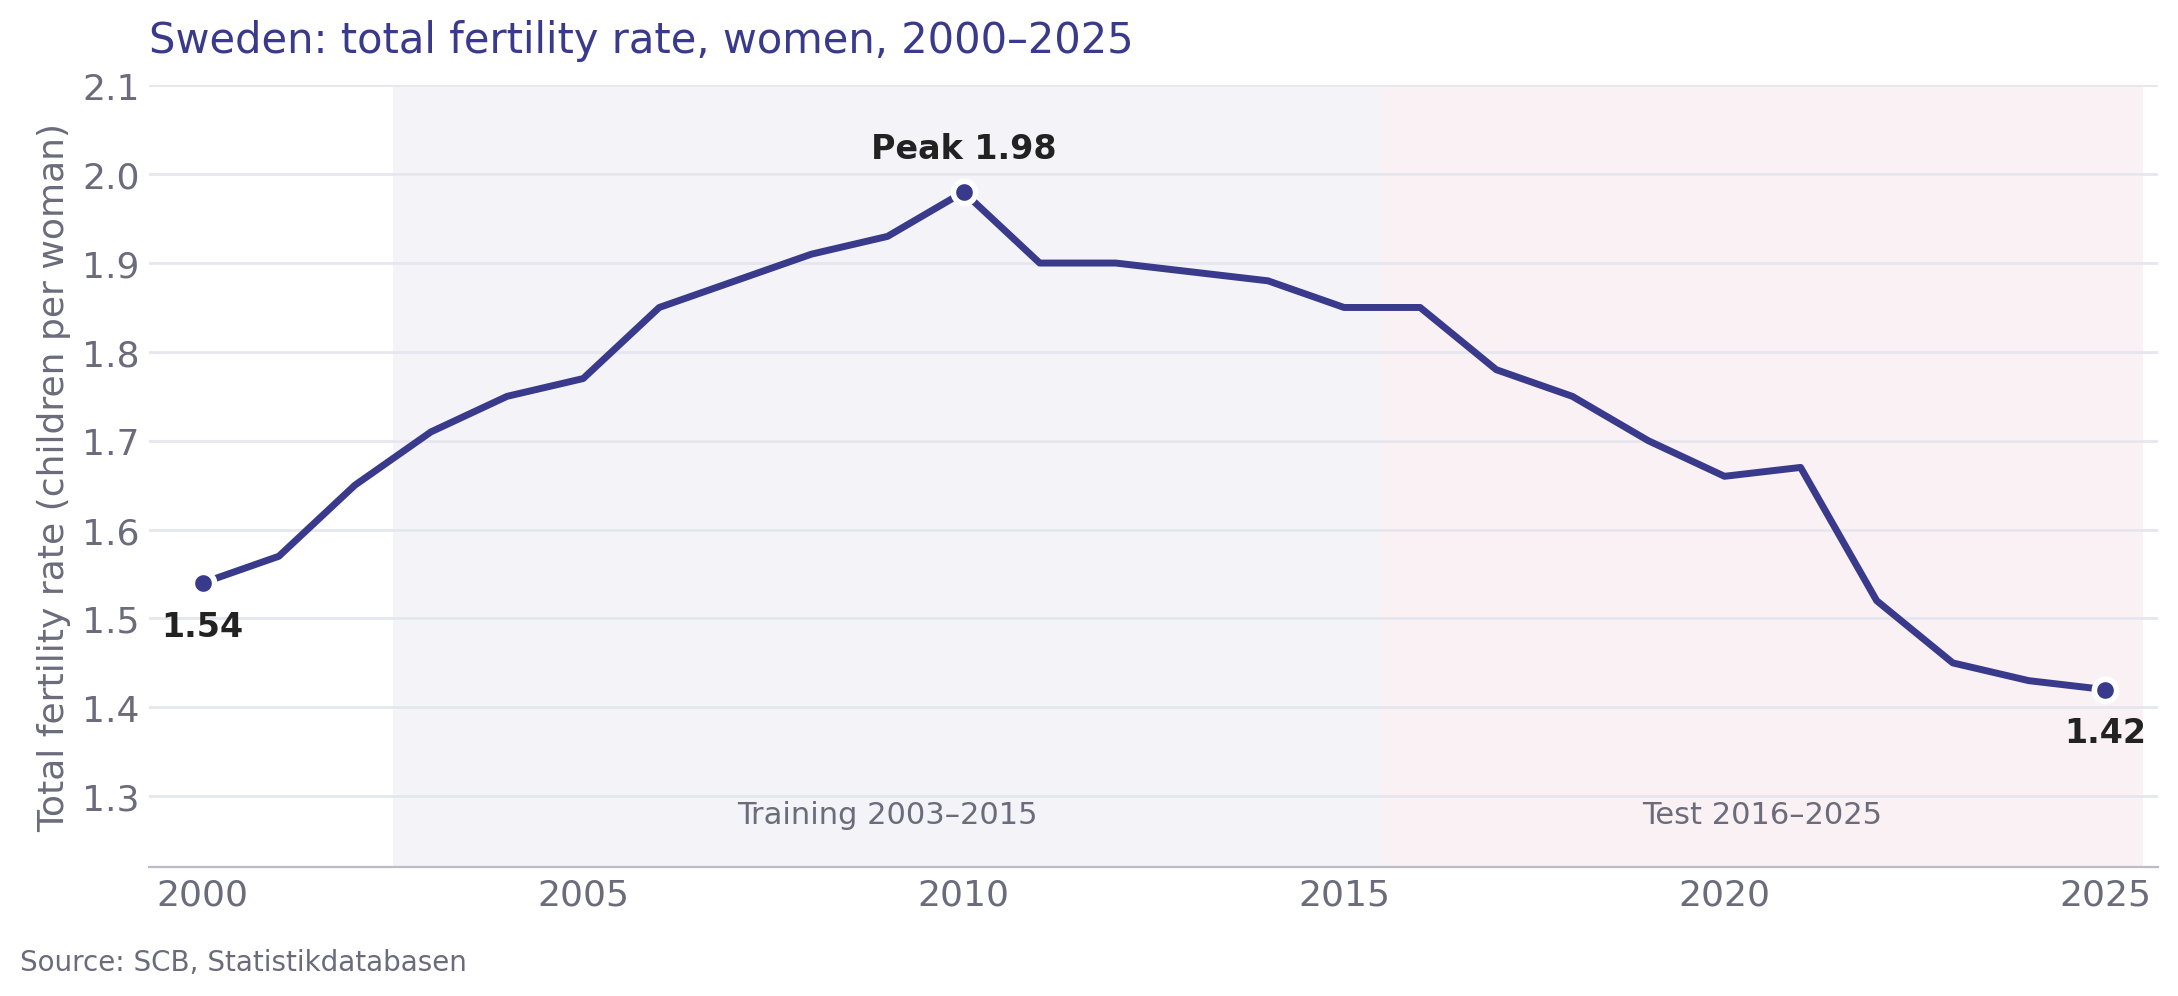

In [ ]:
import matplotlib.pyplot as plt

# Read SCB's national figures (the raw data file)
df = pd.read_csv(RAW/"Fruktbarhet_riket.csv", encoding="utf-8-sig")
kv = df[df["kön"] == "kvinnor"].sort_values("år")
ar, tfr = kv["år"], kv["Summerad fruktsamhet, antal"]

NAVY, PINK, MUTED, GRID = "#3A3A8C", "#B5405F", "#6B6B7B", "#E6E6EE"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 13})
fig, ax = plt.subplots(figsize=(11, 5), dpi=200)

ax.axvspan(2002.5, 2015.5, color=NAVY, alpha=0.06, lw=0)
ax.axvspan(2015.5, 2025.5, color=PINK, alpha=0.07, lw=0)
ax.text(2009, 1.27, "Training 2003–2015", ha="center", color=MUTED, fontsize=11)
ax.text(2020.5, 1.27, "Test 2016–2025", ha="center", color=MUTED, fontsize=11)

ax.plot(ar, tfr, color=NAVY, lw=2.5)
for x, txt, va, dy in [(2000, "1.54", "top", -0.03), (2010, "Peak 1.98", "bottom", 0.03),
                       (2025, "1.42", "top", -0.03)]:
    y = tfr[ar == x].iloc[0]
    ax.plot(x, y, "o", ms=8, color=NAVY, mec="white", mew=2, zorder=3)
    ax.text(x, y + dy, txt, ha="center", va=va, fontsize=12, color="#222", fontweight="bold")

ax.set_ylim(1.22, 2.1)
ax.set_xlim(1999.3, 2025.7)
ax.set_xticks(range(2000, 2026, 5))
ax.set_ylabel("Total fertility rate (children per woman)", color=MUTED)
ax.set_title("Sweden: total fertility rate, women, 2000–2025", loc="left",
             fontsize=15, color=NAVY, pad=12)
ax.grid(axis="y", color=GRID, lw=1)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#BBBBC8")
ax.tick_params(colors=MUTED, length=0)
fig.text(0.01, 0.01, "Source: SCB, Statistikdatabasen", fontsize=10, color=MUTED)

fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("national_trend.png", facecolor="white")